In [1]:
# 실습 준비 - 패키지 설치·폰트·Chronos-2 내려받기·GPU 확인
# [heavy]
#  Colab 이거나 chronos-forecasting · holidays 가 없으면 2.3.1 · 0.103 을 설치합니다. 이미 깔려 있으면 그 버전을 씁니다.
#  numpy · pandas · pyarrow · torch · matplotlib 은 Colab 기본 버전을 그대로 씁니다.
import os, sys, math, time, subprocess
from importlib.util import find_spec
IN_COLAB = "google.colab" in sys.modules
if IN_COLAB or find_spec("chronos") is None or find_spec("holidays") is None:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                    "chronos-forecasting==2.3.1", "holidays==0.103"], check=True)

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import warnings; warnings.filterwarnings("ignore")

# 한글 폰트 — Colab 이면 나눔고딕을 설치한 뒤 그 ttf 를 폰트 목록에 **직접** 등록한다.
#  설치는 디스크에 파일만 만든다. 이미 떠 있는 폰트 목록은 그 사실을 모르므로 addfont 로
#  넣어 줘야 이름이 보인다(넣지 않으면 DejaVu Sans 로 밀려 한글이 전부 □ 로 나온다).
import glob, shutil
if IN_COLAB and shutil.which("apt-get"):
    subprocess.run(["apt-get", "-y", "-qq", "install", "fonts-nanum"], check=False)
for _p in glob.glob("/usr/share/fonts/truetype/nanum/Nanum*.ttf"):   # 설치 여부와 무관하게 한 번
    try: fm.fontManager.addfont(_p)
    except Exception: pass
try: fm._get_font.cache_clear()
except Exception: pass
installed = {f.name for f in fm.fontManager.ttflist}
FONT = next((n for n in ["Pretendard", "Apple SD Gothic Neo", "NanumGothic"] if n in installed), "DejaVu Sans")
plt.rcParams["font.family"] = FONT
plt.rcParams["axes.unicode_minus"] = FONT in {"Pretendard", "DejaVu Sans"}   # 나머지 폰트에는 U+2212 가 없다
%config InlineBackend.print_figure_kwargs = {"bbox_inches": None}   # 그림마다 폭이 깎이지 않게
plt.rcParams["figure.dpi"] = plt.rcParams["savefig.dpi"] = 150       # 폭 FIG_W x 150dpi = 1500px 고정
plt.rcParams["figure.autolayout"] = True
plt.rcParams.update({"font.size": 11, "axes.titlesize": 15, "axes.labelsize": 12,
                     "legend.fontsize": 11, "figure.titlesize": 17, "font.weight": "regular",
                     "text.color": "black", "axes.labelcolor": "black", "axes.titlecolor": "black",
                     "axes.edgecolor": "#757575", "xtick.color": "#757575", "ytick.color": "#757575",
                     "xtick.labelcolor": "black", "ytick.labelcolor": "black",
                     "axes.spines.top": False, "axes.spines.right": False, "axes.grid": False})

# 그림 전체가 함께 쓰는 색 — 베이스라인=남색, 관측=파랑, 강조=하늘색, 문맥=회색
COL = {"남색": "#051C2C", "파랑": "#2251FF", "하늘색": "#00A9F4",
       "회색": "#757575", "연회색": "#B3B3B3"}
FIG_W = 10.0     # 캔버스 폭은 그림 모두 이 값으로 고정하고 높이만 그림마다 조절한다
FIGW = FIG_W      # 도우미가 밑줄을 빼고 FIGW 로 옮겨 적는 일이 있어 같은 값을 하나 더 둔다
print("사용 폰트:", FONT, "| 색 팔레트 준비 완료")

# Chronos-2 가중치(약 480MB)를 여기서 한 번 내려받아 둡니다 — 「오늘의 준비」 셀과 미션 준비 셀은 이 사본을 읽습니다.
#  내려받기가 끊기면 10초 쉬고 다시 시도하며, 세 번까지 합니다.
from huggingface_hub import snapshot_download
CHRONOS_ID = "amazon/chronos-2"
for _try in range(1, 4):
    try:
        snapshot_download(CHRONOS_ID, allow_patterns=["config.json", "model.safetensors"])
        print(f"Chronos-2 가중치 준비 완료 — {CHRONOS_ID} ({_try}번째 시도)")
        break
    except Exception as _e:
        print(f"Chronos-2 내려받기 {_try}번째 실패 — {type(_e).__name__}")
        if _try < 3:
            time.sleep(10)
else:   # 받지 못한 채 넘어가면 뒤 셀의 from_pretrained 가 내려받기 오류로 멈춘다 — 여기서 멈춘다
    raise RuntimeError("Chronos-2 가중치를 세 번 모두 받지 못했습니다. LMS 면 이 셀을 다시 실행하고, 그래도 같으면"
                       " 강사에게 알립니다. Colab 이면 메뉴 런타임 → 런타임 다시 시작을 누른 뒤 이 셀부터 다시 실행합니다")

# GPU 확인 — Chronos-2 예측은 여기서 정한 DEVICE 에서 실행됩니다
from importlib.metadata import version
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
torch.backends.cuda.matmul.allow_tf32 = False   # fp32 로 계산합니다 — GPU 종류(T4·L4·A100)에 따라 결과가 갈리지 않게
torch.backends.cudnn.allow_tf32 = False
print(f"DEVICE : {DEVICE} | torch {torch.__version__} | chronos-forecasting {version('chronos-forecasting')}")
if DEVICE == "cuda":
    _props = torch.cuda.get_device_properties(0)
    print(f"GPU : {torch.cuda.get_device_name(0)} · 메모리 {_props.total_memory / 1e9:.1f} GB — 준비됐습니다")
else:
    print("GPU 가 연결되지 않았습니다. 메뉴 런타임 → 런타임 유형 변경 → GPU 를 고른 뒤 맨 위 셀부터 다시 실행합니다.")
    print("그대로 두면 같은 코드가 CPU 에서 더 느리게 실행되고, 값은 이 노트북에 적힌 값과 같게 나옵니다.")
if version("chronos-forecasting") != "2.3.1" or not torch.__version__.startswith("2.11."):
    print("참고 — 교안의 수는 torch 2.11.0 · chronos-forecasting 2.3.1 에서 계산했습니다."
          " 지금 버전에서는 소수점 아래 값이 조금 다를 수 있습니다.")

사용 폰트: DejaVu Sans | 색 팔레트 준비 완료


Fetching 2 files: 100%|██████████| 2/2 [00:00<00:00, 6293.03it/s]

Chronos-2 가중치 준비 완료 — amazon/chronos-2 (1번째 시도)
DEVICE : cpu | torch 2.14.1+cpu | chronos-forecasting 2.3.1
GPU 가 연결되지 않았습니다. 메뉴 런타임 → 런타임 유형 변경 → GPU 를 고른 뒤 맨 위 셀부터 다시 실행합니다.
그대로 두면 같은 코드가 CPU 에서 더 느리게 실행되고, 값은 이 노트북에 적힌 값과 같게 나옵니다.
참고 — 교안의 수는 torch 2.11.0 · chronos-forecasting 2.3.1 에서 계산했습니다. 지금 버전에서는 소수점 아래 값이 조금 다를 수 있습니다.


In [2]:
font_path = "C:/Windows/Fonts/malgun.ttf"
fm.fontManager.addfont(font_path)
plt.rcParams["font.family"] = fm.FontProperties(fname=font_path).get_name()
plt.rcParams["axes.unicode_minus"] = False

Loading weights: 100%|██████████| 170/170 [00:00<00:00, 731.99it/s]


행렬 : 100개 역 x 4,199일 · 2015-01-01 ~ 2026-06-30
Chronos-2 : amazon/chronos-2 · fp32 · DEVICE cpu · 불러오기 1.5초 · 원점 넷 예측 7.7초 · 학습 없음

표 1 · 계절 나이브의 예측 원점별 MASE (배)
예측 원점   2025-08-13  2025-10-01  2025-12-10  2026-02-11  2026-06-24
계절 나이브       1.069       4.388       0.419       2.844       0.471
두 묶음 평균 : 공휴일 없는 두 주 0.445 · 공휴일 있는 세 주 2.767

표 2 · 강남역 원점 2026-06-24 Chronos-2 제로샷 예측과 실제 (명)
        06-24(수) 06-25(목) 06-26(금) 06-27(토) 06-28(일) 06-29(월) 06-30(화)
실제        94,303   94,077   98,456   67,630   40,248   89,909   92,064
0.1 분위수   90,183   90,044   91,775   59,391   31,381   79,432   81,366
0.5 분위수   94,030   94,683   96,552   67,342   39,453   89,875   91,981
0.9 분위수   96,069   96,606   98,878   71,988   44,704   92,958   94,357


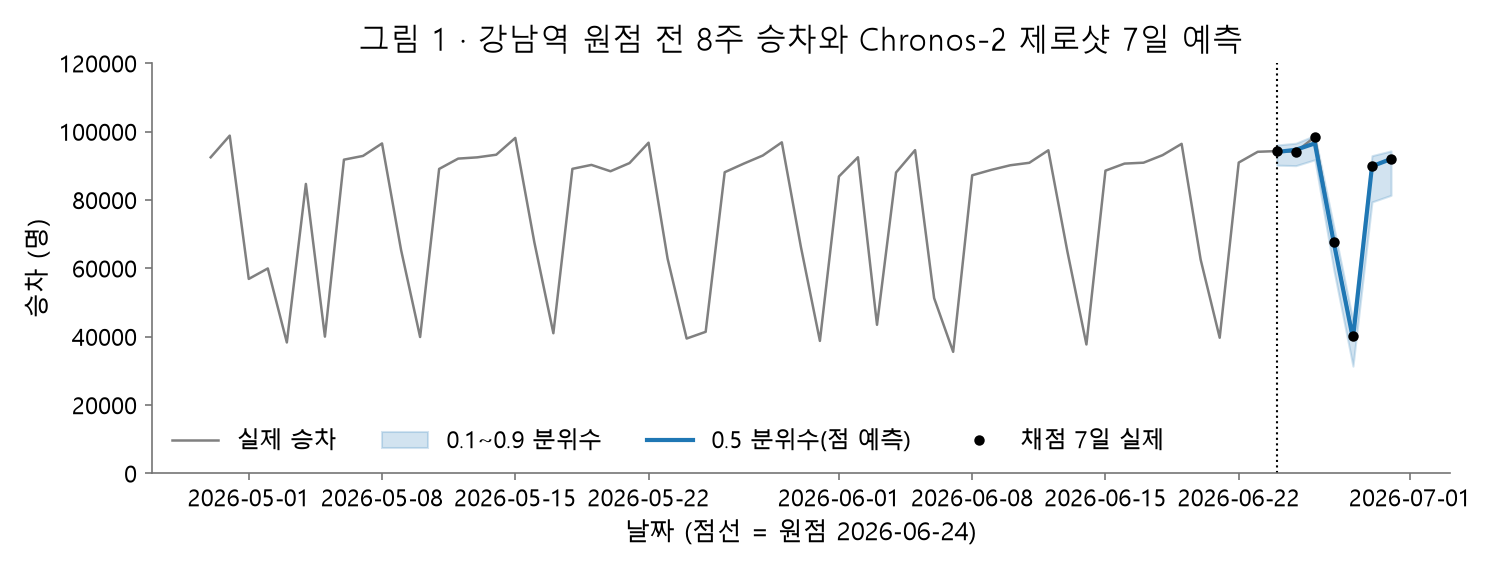

표 3 · 강남역 컨텍스트 512일의 요일별 평균 승차 (명)
컨텍스트 2025-01-28 ~ 2026-06-23 (512일, 마지막 날 = 원점 전날)
            월       화       수       목       금       토       일
평균 승차  84,185  86,126  87,300  88,017  92,868  63,891  37,458

표 4 · 공휴일 있는 세 주의 평일, 100개 역 예측 합 ÷ 실제 합 (배)
평일 공휴일 6일 : 2025-08-15 · 2025-10-03 · 2025-10-06 · 2025-10-07 · 2026-02-16 · 2026-02-17
              평일 공휴일 6일 공휴일 아닌 평일 9일 6일 모두 실제보다 높게 예측한 역
Chronos-2 제로샷    2.139배       1.001배               96개 역
계절 나이브           2.143배       0.998배               95개 역


In [3]:
# 오늘의 준비 — 읽고 실행만 합니다
# 서울 지하철 100개 역으로 표 1 · 표 2 · 그림 1 · 표 3 · 표 4 를 만듭니다. Chronos-2 는 원점 넷에 한 번씩 부르고 학습은 하지 않습니다
# Chronos-2 를 불러오다 내려받기 오류(Hugging Face)가 나면 맨 위 설치 셀부터 다시 실행합니다
import os, time
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import holidays

RAW_URL = "https://github.com/studio-js/seoul-subway-ridership/raw/main/data/seoul_subway_daily_2015_2026.parquet"
CACHE = "seoul_subway_daily.parquet"          # 한 번 받아 두면 다시 받지 않습니다
if not os.path.exists(CACHE):
    pd.read_parquet(RAW_URL).to_parquet(CACHE)

# 첫날과 같은 손질: 역 이름의 괄호 별칭을 떼고 9호선 이름을 맞춘 뒤 (날짜, 호선, 역) 으로 합칩니다
_raw = pd.read_parquet(CACHE)
_raw["date"] = pd.to_datetime(_raw["date"])
_raw["station"] = _raw["station"].astype(str).str.replace(r"\(.*\)$", "", regex=True)
_raw["line"] = _raw["line"].astype(str).replace({"9호선2단계": "9호선(2~3단계)",
                                                "9호선2~3단계": "9호선(2~3단계)"})
_clean = _raw.groupby(["date", "line", "station"], as_index=False,
                      observed=True)[["board", "alight"]].sum()
_span = _clean.groupby(["line", "station"])["date"].agg(["min", "max", "count"])
_full = _span[(_span["min"] <= pd.Timestamp("2015-01-01")) &            # 기록이 끊기지 않은 역만 남긴 뒤
              (_span["max"] >= pd.Timestamp("2026-06-30")) & (_span["count"] >= 4190)]
_top = (_clean[_clean["date"] <= pd.Timestamp("2024-12-31")]             # 2024년까지 평균 승차 상위 100개 역
        .groupby(["line", "station"])["board"].mean()
        .loc[_full.index].sort_values(ascending=False).index[:100])
_wide = _clean.pivot_table(index=["line", "station"], columns="date", values="board").loc[_top]

MAT = _wide.to_numpy(dtype=float)             # 100개 역 x 4,199일 승차 (명)
DATES = pd.DatetimeIndex(_wide.columns)       # 표 열의 날짜
STATIONS = [f"{_line} {_name}" for _line, _name in _wide.index]   # 표 행의 역 이름

ORIGINS = ["2025-08-13", "2025-10-01", "2025-12-10", "2026-02-11", "2026-06-24"]   # 예측 원점 5개 (수요일)
PLAIN_ORIGINS = ["2025-12-10", "2026-06-24"]                                       # 공휴일 없는 두 주
HOL_ORIGINS = ["2025-08-13", "2025-10-01", "2026-02-11"]                           # 공휴일 있는 세 주
H, CTX = 7, 512                               # 채점 7일 · 컨텍스트 512일
QS = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]   # Chronos-2 가 내는 분위수 아홉 개 (점 예측은 0.5)
SEED = 0                                      # 시드
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"   # 설치 셀과 같은 규칙, 이 셀만 실행해도 정해집니다
torch.backends.cuda.matmul.allow_tf32 = False            # fp32 로 계산합니다


def origin_ctx(origin):
    """원점 하나의 자료 — 원점의 열 번호(o), 원점 전날까지의 100개 역(hist), 채점 7일(test, 명), 역별 MASE 분모(qden)"""
    o = int(DATES.get_loc(pd.Timestamp(origin)))
    hist = MAT[:, :o]
    qden = np.nanmean(np.abs(hist[:, 7:] - hist[:, :-7]), axis=1)   # 원점 전날까지로 계산한 분모
    return dict(o=o, hist=hist, test=MAT[:, o:o + H], qden=qden)


# 계절 나이브: 원점 전 7일(1주일 전 같은 요일 값)을 그대로 7일 예측으로 씁니다
SN_MASE = {}                                  # 원점 → 계절 나이브의 100개 역 평균 MASE
for _d in ORIGINS:
    _c = origin_ctx(_d)
    SN_MASE[_d] = float(np.mean(np.abs(_c["test"] - MAT[:, _c["o"] - 7:_c["o"]]) / _c["qden"][:, None]))
SN_PLAIN = float(np.mean([SN_MASE[_d] for _d in PLAIN_ORIGINS]))
SN_HOL = float(np.mean([SN_MASE[_d] for _d in HOL_ORIGINS]))

# Chronos-2 를 DEVICE 에 올리고, 원점마다 100개 역의 원점 전날까지 512일을 롱 포맷 표 하나로 넘겨 7일을 한 번에 받습니다
from chronos import BaseChronosPipeline
_t0 = time.perf_counter()
PIPE = BaseChronosPipeline.from_pretrained("amazon/chronos-2", device_map=DEVICE, torch_dtype=torch.float32)
_load_sec = time.perf_counter() - _t0
_n_st, _g = len(STATIONS), STATIONS.index("2호선 강남")
_point, _t1 = {}, time.perf_counter()        # _point: 원점 → 100개 역 x 7일 점 예측("0.5" 열)
for _d in ["2026-06-24"] + HOL_ORIGINS:
    _o = origin_ctx(_d)["o"]
    _long = pd.DataFrame({"item_id": np.repeat(np.arange(_n_st), CTX),           # 역 · 날짜 · 승차 세 열
                          "timestamp": np.tile(DATES[_o - CTX:_o].values, _n_st),
                          "target": MAT[:, _o - CTX:_o].ravel()})
    torch.manual_seed(SEED)
    _fc = PIPE.predict_df(_long, prediction_length=H, quantile_levels=QS, context_length=CTX, freq="D")
    _fc = _fc.sort_values(["item_id", "timestamp"])
    _point[_d] = _fc["0.5"].to_numpy().reshape(_n_st, H)
    if _d == "2026-06-24":
        _gfc = _fc[_fc["item_id"] == _g]
_pred_sec = time.perf_counter() - _t1

# 표 2 · 표 3 의 값: 강남역 원점 2026-06-24
_o = origin_ctx("2026-06-24")["o"]
GN_FC = pd.DataFrame({"actual": MAT[_g, _o:_o + H], "0.1": _gfc["0.1"].to_numpy(),
                      "0.5": _gfc["0.5"].to_numpy(), "0.9": _gfc["0.9"].to_numpy()}, index=DATES[_o:_o + H])
GN_CTX_LAST = DATES[_o - 1]                   # 컨텍스트 마지막 날 = 원점 전날
_ctx = DATES[_o - CTX:_o]
_DOW = ["월", "화", "수", "목", "금", "토", "일"]
GN_DOW = pd.Series(MAT[_g, _o - CTX:_o], index=_ctx).groupby(_ctx.dayofweek).mean()
GN_DOW.index = _DOW

# 표 4 의 값: 공휴일 있는 세 주의 채점 7일 가운데 평일(월~금)을 공휴일 6일과 공휴일 아닌 날 9일로 나눕니다
_kr = holidays.KR(years=[2025, 2026])
_hol6, _wk9 = [], []                          # (원점, 원점부터 며칠째) 목록
for _d in HOL_ORIGINS:
    for _k in range(H):
        _day = DATES[origin_ctx(_d)["o"] + _k]
        if _day.dayofweek < 5:
            (_hol6 if _day.date() in _kr else _wk9).append((_d, _k))
HOL_DAYS = [str(DATES[origin_ctx(_d)["o"] + _k].date()) for _d, _k in _hol6]
_pred_of = {"Chronos-2 제로샷": lambda d: _point[d],
            "계절 나이브": lambda d: MAT[:, origin_ctx(d)["o"] - 7:origin_ctx(d)["o"]]}


def _sum_ratio(pred, days):
    """고른 날들의 100개 역 예측 합 ÷ 실제 합"""
    return float(sum(pred(_d)[:, _k].sum() for _d, _k in days)
                 / sum(origin_ctx(_d)["test"][:, _k].sum() for _d, _k in days))


HOL_RATIO = pd.DataFrame({"hol6": {m: _sum_ratio(f, _hol6) for m, f in _pred_of.items()},
                          "wk9": {m: _sum_ratio(f, _wk9) for m, f in _pred_of.items()}})
HOL_ALLOVER = {m: int(np.all([f(_d)[:, _k] > origin_ctx(_d)["test"][:, _k] for _d, _k in _hol6], axis=0).sum())
               for m, f in _pred_of.items()}   # 평일 공휴일 6일 모두 실제보다 높게 예측한 역 수

# 자료 확인 (출력 없음) — 계절 나이브 다섯 값, 강남 MASE 분모, 컨텍스트 기간, Chronos-2 가 입력을 16일씩 묶는 패치 크기, 표 4
assert MAT.shape == (100, 4199)
assert [round(SN_MASE[_d], 3) for _d in ORIGINS] == [1.069, 4.388, 0.419, 2.844, 0.471]
assert (round(SN_PLAIN, 3), round(SN_HOL, 3)) == (0.445, 2.767)
assert round(float(origin_ctx("2026-06-24")["qden"][_g]), 1) == 7813.8
assert (str(_ctx[0].date()), str(GN_CTX_LAST.date())) == ("2025-01-28", "2026-06-23")
assert PIPE.model.chronos_config.input_patch_size == 16
assert HOL_DAYS == ["2025-08-15", "2025-10-03", "2025-10-06", "2025-10-07", "2026-02-16", "2026-02-17"]
assert abs(HOL_RATIO.loc["Chronos-2 제로샷", "hol6"] - 2.14) < 0.02 and 94 <= HOL_ALLOVER["Chronos-2 제로샷"] <= 98

print(f"행렬 : {MAT.shape[0]}개 역 x {MAT.shape[1]:,}일 · {DATES[0].date()} ~ {DATES[-1].date()}")
print(f"Chronos-2 : amazon/chronos-2 · fp32 · DEVICE {DEVICE} · 불러오기 {_load_sec:.1f}초"
      f" · 원점 넷 예측 {_pred_sec:.1f}초 · 학습 없음")
print()
print("표 1 · 계절 나이브의 예측 원점별 MASE (배)")
_tab1 = pd.DataFrame([SN_MASE], index=["계절 나이브"]).round(3)
_tab1.columns.name = "예측 원점"
print(_tab1.to_string())
print(f"두 묶음 평균 : 공휴일 없는 두 주 {SN_PLAIN:.3f} · 공휴일 있는 세 주 {SN_HOL:.3f}")
print()
print("표 2 · 강남역 원점 2026-06-24 Chronos-2 제로샷 예측과 실제 (명)")
_tab2 = GN_FC.T.round().astype(int).map("{:,}".format)
_tab2.index = ["실제", "0.1 분위수", "0.5 분위수", "0.9 분위수"]
_tab2.columns = [f"{_x:%m-%d}({_DOW[_x.dayofweek]})" for _x in GN_FC.index]
print(_tab2.to_string())

_win = slice(_o - 56, _o + H)                 # 원점 전 8주와 채점 7일
fig, ax = plt.subplots(figsize=(10, 3.8))
ax.plot(DATES[_win], MAT[_g, _win], color="gray", lw=1.2, label="실제 승차")
ax.fill_between(GN_FC.index, GN_FC["0.1"], GN_FC["0.9"], color="tab:blue", alpha=0.2, label="0.1~0.9 분위수")
ax.plot(GN_FC.index, GN_FC["0.5"], color="tab:blue", lw=2, label="0.5 분위수(점 예측)")
ax.plot(GN_FC.index, GN_FC["actual"], "o", color="black", ms=4, label="채점 7일 실제")
ax.axvline(DATES[_o], color="black", ls=":", lw=1)
ax.set_ylim(0, 120000)
ax.set_title("그림 1 · 강남역 원점 전 8주 승차와 Chronos-2 제로샷 7일 예측")
ax.set(xlabel="날짜 (점선 = 원점 2026-06-24)", ylabel="승차 (명)")
ax.legend(loc="lower left", ncol=4, frameon=False)
plt.show()

print("표 3 · 강남역 컨텍스트 512일의 요일별 평균 승차 (명)")
print(f"컨텍스트 {_ctx[0].date()} ~ {GN_CTX_LAST.date()} ({CTX}일, 마지막 날 = 원점 전날)")
print(GN_DOW.round().astype(int).map("{:,}".format).to_frame("평균 승차").T.to_string())
print()
print("표 4 · 공휴일 있는 세 주의 평일, 100개 역 예측 합 ÷ 실제 합 (배)")
print("평일 공휴일 6일 : " + " · ".join(HOL_DAYS))
_tab4 = pd.DataFrame({"평일 공휴일 6일": HOL_RATIO["hol6"].map("{:.3f}배".format),
                    "공휴일 아닌 평일 9일": HOL_RATIO["wk9"].map("{:.3f}배".format),
                    "6일 모두 실제보다 높게 예측한 역": pd.Series(HOL_ALLOVER).map("{}개 역".format)})
print(_tab4.to_string())

# 원점 당일의 열 번호가 o 일 때 MAT[:, o - 512:o] 가 담는 날
100개 역 × 날짜 표 MAT 에서 원점 2026-06-24 의 열 번호가 o 라고 합시다.

B. 원점 전날까지 512일이고, 채점 7일의 값은 입력에 없다

원점 전날까지 512일이고, 채점 7일의 값은 입력에 없습니다. 파이썬 자르기 a:b 는 끝 번호 b 를 포함하지 않아, o - 512:o 의 마지막 열이 o - 1, 곧 원점 전날이기 때문입니다. 이론 「3. Chronos-2 의 입력과 출력」의 컨텍스트 512일도 같은 규칙으로 원점 전날에서 끝납니다.

열 번호로 세면 o - 512, o - 511, …, o - 1 이라 o − (o − 512) = 512개 열입니다. 원점 2026-06-24 이면 첫 열은 2025-01-28, 마지막 열은 2026-06-23 입니다. 첫날 MLP 의 입력 28일을 원점 전날에서 끝낸 것과 같은 규칙입니다.

원점 당일까지 512일이라 채점 첫날의 실제값이 입력에 있다: 끝 번호 o 까지 포함한다고 읽은 것입니다. 원점 당일까지 자르려면 o - 511:o + 1 이어야 하고, 그러면 채점 첫날 2026-06-24 의 실제값(강남 94,303명)이 입력에 있어 그날 점수가 운영에서 받을 점수보다 좋게 나옵니다.
이 512일로 가중치를 다시 학습한 뒤 예측한다: 미세조정의 설명입니다. 제로샷은 가중치를 고치지 않고, 512일은 예측할 때의 입력으로만 씁니다.
그래서 미션 1 에서도 원점마다 컨텍스트 첫날과 마지막 날을 출력해 마지막 날이 원점 전날인지 확인합니다. 채점 항목은 아니고, 미션 1 「내가 확인할 일」 표의 첫 행입니다.

핵심 키워드: 자르기는 끝 번호를 포함하지 않는다, 컨텍스트 마지막 날은 원점 전날, 제로샷은 가중치를 고치지 않는다

# 채점 7일 동안 날마다 실제값을 넣어 다시 예측하면 무엇을 채점하나

A. 원점 당일 아침에는 낼 수 없는 예측을 채점해, 운영에서 받을 오차보다 작게 나온다

원점 당일 아침에는 낼 수 없는 예측을 채점해, 운영에서 받을 오차보다 작게 나옵니다. 평가표의 수는 원점 전날까지의 입력으로 7일을 한 번에 예측(multi-step forecast)한 값인데, 날마다 다시 예측(rolling forecast)하면 원점 뒤 실측이 입력에 있기 때문입니다(이론 「3. Chronos-2 의 입력과 출력」).

원점 2026-06-24(수)에서 6월 27일(토)을 예측한다고 해 봅니다. 7일을 한 번에 예측하면 입력이 6월 23일(화)에서 끝나고, 토요일은 원점 전날에서 4일 뒤 예측입니다. 날마다 다시 예측하면 입력이 6월 26일(금)에서 끝나 원점 뒤 실측 3일(수·목·금)이 입력에 있고, 토요일도 하루 뒤 예측이 됩니다. 수요일 아침에는 이 3일의 실측이 없으므로 이 채점은 운영에서 받을 오차보다 작게 나옵니다.

같은 512일이니 같은 값이 나온다: 입력의 마지막 날이 날마다 하루씩 뒤로 옮겨 간다는 점을 놓친 것입니다. 두 방식의 입력이 같은 날은 원점 당일(6월 24일, 입력 끝 6월 23일) 하루뿐입니다.
하루씩 예측하면 오차가 누적돼 더 크게 나온다: 방향이 반대입니다. 방금 낸 예측값을 다음 날 입력으로 쓴다면 오차가 다음 날로 넘어가지만, 날마다 다시 예측할 때는 예측값 대신 그날의 실제값을 입력으로 씁니다. 그래서 앞선 날의 예측 오차가 다음 입력으로 넘어가지 않고, 7일째 예측도 하루 뒤 예측이 됩니다.
그래서 평가표에는 원점 전날까지의 입력으로 7일을 한 번에 예측한 값만 적습니다. 다른 사람이 보고한 점수를 받으면 원점마다 입력의 마지막 날부터 확인합니다.

핵심 키워드: 원점 당일 아침의 조건, 날마다 다시 예측(rolling forecast), 7일을 한 번에 예측(multi-step forecast)

# 강남역 주말 예측이 낮은 까닭
「오늘의 준비」 셀을 실행하면 나오는 「표 2 · 강남역 원점 2026-06-24 Chronos-2 제로샷 예측과 실제 (명)」과 「표 3 · 강남역 컨텍스트 512일의 요일별 평균 승차 (명)」을 봅니다. 이 노트북의 Chronos-2 제로샷이 토·일을 낮게 예측한 까닭은?

A. 입력 512일에 토·일이 낮은 요일 모양이 있어 거기서 읽었다

입력 512일에 토·일이 낮은 요일 모양이 있어 거기서 읽었습니다. 제로샷은 가중치를 고치지 않으므로, 강남역의 요일 모양은 입력으로 받은 512일에서 읽기 때문입니다(이론 「1. 사전학습·제로샷·미세조정」).

두 표 모두 수요일과 비교합니다. 표 3 의 컨텍스트 512일 평균은 수요일 87,300명, 토요일 63,891명, 일요일 37,458명입니다. 토요일은 63,891 ÷ 87,300 ≈ 0.73배, 일요일은 37,458 ÷ 87,300 ≈ 0.43배입니다. 표 2 의 0.5 분위수는 수요일 06-24 94,030명, 토요일 06-27 67,342명, 일요일 06-28 39,453명입니다. 토요일은 67,342 ÷ 94,030 ≈ 0.72배, 일요일은 39,453 ÷ 94,030 ≈ 0.42배라, 입력과 예측의 요일 비가 0.01 안쪽으로 같습니다.

원점마다 강남역 512일로 가중치를 조금 고쳐 요일 모양을 배웠다: 가중치를 고치는 미세조정의 설명이라 제로샷과 반대입니다. 「오늘의 준비」 셀은 Chronos-2 를 원점 넷에 한 번씩 부르기만 하고, 출력의 「Chronos-2 :」 줄 끝에도 「학습 없음」이 찍힙니다.
채점 7일의 실제값이 입력에 있어 주말 값을 미리 보았다: 표 3 의 컨텍스트 마지막 날이 2026-06-23, 곧 원점 전날이라 채점 7일(06-24～06-30)은 입력에 없습니다. Chronos-2 는 기술 보고서를 낸 2025-10-17 전에 사전학습을 마쳤으므로, 그 뒤 날짜인 채점 7일은 사전학습 자료에도 없습니다.
그래서 제로샷에도 그 역의 과거 512일은 꼭 입력합니다. 이번 주 다른 역을 예측할 때도 원점 전날까지 512일을 입력했는지 확인하고, 표 3 처럼 요일별 평균을 한 번 출력해 입력에 요일 모양이 있는지 봅니다.

핵심 키워드: 요일 모양은 입력 512일에서, 제로샷은 가중치를 고치지 않는다, 컨텍스트 마지막 날

# 평일 공휴일이 있는 주의 역별 인력
「오늘의 준비」 셀을 실행하면 나오는 「표 4 · 공휴일 있는 세 주의 평일, 100개 역 예측 합 ÷ 실제 합 (배)」를 봅니다. 평일 공휴일이 있는 주의 역별 인력을 Chronos-2 제로샷 예측으로 정해도 될까요?

C. 공휴일 날은 이 예측으로 정하지 않고 공휴일 아닌 날만 쓴다. 평일 공휴일에는 계절 나이브처럼 실제의 약 2배를 예측했다

공휴일 날은 이 예측으로 정하지 않고 공휴일 아닌 날만 씁니다. 표 4 에서 평일 공휴일 6일의 100개 역 예측 합이 실제 합의 2.139배로, 실제의 약 2배를 예측했기 때문입니다(1주일 전 값을 그대로 쓰는 계절 나이브 2.143배와 거의 같습니다). 역마다 보아도 6일 모두 실제보다 높게 예측한 역이 100개 역 가운데 96개 역입니다. 예측할 7일 가운데 어느 날이 공휴일인지가 입력에 없어서입니다(이론 「5. 평일 공휴일 과대 예측」).

평일 공휴일 6일은 2025-08-15 · 2025-10-03 · 2025-10-06 · 2025-10-07 · 2026-02-16 · 2026-02-17 입니다. 공휴일 있는 세 주의 평일은 3주 × 5일 = 15일이라, 15 − 6 = 9일이 공휴일 아닌 평일입니다. 평일 공휴일 6일 동안은 실제 100명마다 약 214명을 예측한 셈입니다. 공휴일 아닌 평일 9일은 1.001배라 실제와 거의 같습니다.

정해도 된다, 512일 입력에 지난 설·추석이 있다: 지난 공휴일은 낮은 승차 값으로만 입력에 있고, 예측할 7일 가운데 어느 날이 공휴일인지는 입력에 없습니다. 그래서 평일 공휴일 6일을 평일처럼 예측해 2.139배가 나왔습니다.
정해도 된다, 공휴일 아닌 평일 9일의 합이 실제와 거의 같다: 공휴일 아닌 9일(1.001배)만 보고 공휴일 6일(2.139배)을 빠뜨린 것입니다. 9일이 맞아도 공휴일 6일의 인력은 실제의 약 2배로 잡힙니다.
그래서 평일 공휴일이 있는 주에는 공휴일 날의 인력을 이 예측으로 정하지 않고, 공휴일 아닌 날의 예측만 씁니다. 이번 주 인력 계획표에는 평일 공휴일 날을 따로 표시해 두고, 그날 인력은 이 예측 대신 운영팀이 정한다고 적습니다.

핵심 키워드: 평일 공휴일 6일과 평일 9일을 나눠 읽기, 공휴일 날짜는 입력에 없다, 계절 나이브와 같은 배수

In [4]:
# 미션 1 · 준비 — 읽고 실행만 합니다. 이 셀이 미션 1 에 쓸 이름을 직접 만듭니다
import os, time
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

RAW_URL = "https://github.com/studio-js/seoul-subway-ridership/raw/main/data/seoul_subway_daily_2015_2026.parquet"
CACHE = "seoul_subway_daily.parquet"          # 한 번 받아 두면 다시 받지 않습니다
if not os.path.exists(CACHE):
    pd.read_parquet(RAW_URL).to_parquet(CACHE)

# 첫날과 같은 손질: 역 이름의 괄호 별칭을 떼고 9호선 이름을 맞춘 뒤 (날짜, 호선, 역) 으로 합칩니다
_raw = pd.read_parquet(CACHE)
_raw["date"] = pd.to_datetime(_raw["date"])
_raw["station"] = _raw["station"].astype(str).str.replace(r"\(.*\)$", "", regex=True)
_raw["line"] = _raw["line"].astype(str).replace({"9호선2단계": "9호선(2~3단계)",
                                                "9호선2~3단계": "9호선(2~3단계)"})
_clean = _raw.groupby(["date", "line", "station"], as_index=False,
                      observed=True)[["board", "alight"]].sum()
_span = _clean.groupby(["line", "station"])["date"].agg(["min", "max", "count"])
_full = _span[(_span["min"] <= pd.Timestamp("2015-01-01")) &            # 기록이 끊기지 않은 역만 남긴 뒤
              (_span["max"] >= pd.Timestamp("2026-06-30")) & (_span["count"] >= 4190)]
_top = (_clean[_clean["date"] <= pd.Timestamp("2024-12-31")]             # 2024년까지 평균 승차 상위 100개 역
        .groupby(["line", "station"])["board"].mean()
        .loc[_full.index].sort_values(ascending=False).index[:100])
_wide = _clean.pivot_table(index=["line", "station"], columns="date", values="board").loc[_top]

MAT = _wide.to_numpy(dtype=float)             # 100개 역 x 4,199일 승차 (명)
DATES = pd.DatetimeIndex(_wide.columns)       # 표 열의 날짜
STATIONS = [f"{_line} {_name}" for _line, _name in _wide.index]   # 표 행의 역 이름

ORIGINS = ["2025-08-13", "2025-10-01", "2025-12-10", "2026-02-11", "2026-06-24"]   # 예측 원점 5개 (수요일)
PLAIN_ORIGINS = ["2025-12-10", "2026-06-24"]                                       # 공휴일 없는 두 주
HOL_ORIGINS = ["2025-08-13", "2025-10-01", "2026-02-11"]                           # 공휴일 있는 세 주
H, CTX = 7, 512                               # 채점 7일 · 컨텍스트 512일
QS = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]   # Chronos-2 가 내는 분위수 아홉 개 (점 예측은 0.5)
SEED = 0                                      # 시드
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"   # 설치 셀과 같은 규칙, 이 셀만 실행해도 정해집니다
torch.backends.cuda.matmul.allow_tf32 = False            # fp32 로 계산합니다


def origin_ctx(origin):
    """원점 하나의 자료 — 원점의 열 번호(o), 원점 전날까지의 100개 역(hist), 채점 7일(test, 명), 역별 MASE 분모(qden)"""
    o = int(DATES.get_loc(pd.Timestamp(origin)))
    hist = MAT[:, :o]
    qden = np.nanmean(np.abs(hist[:, 7:] - hist[:, :-7]), axis=1)   # 원점 전날까지로 계산한 분모
    return dict(o=o, hist=hist, test=MAT[:, o:o + H], qden=qden)


def score(y, pred, qden):
    """MASE(역마다 분모로 나눈 절대 오차의 평균)와 RMSE(명)를 사전으로 돌려줍니다"""
    y, pred = np.asarray(y, dtype=float), np.asarray(pred, dtype=float)
    q = np.asarray(qden, dtype=float).reshape(-1, 1)
    return dict(mase=float(np.mean(np.abs(y - pred) / q)),
                rmse=float(np.sqrt(np.mean((y - pred) ** 2))))


def mase_by_station(y, pred, qden):
    """역마다 MASE(채점 7일 절대 오차 ÷ MASE 분모의 평균)를 구해 100개를 돌려줍니다"""
    y, pred = np.asarray(y, dtype=float), np.asarray(pred, dtype=float)
    return np.mean(np.abs(y - pred) / np.asarray(qden, dtype=float).reshape(-1, 1), axis=1)


SN_ST = {}                                    # 원점 날짜 → 계절 나이브(1주일 전 같은 요일 값)의 역별 MASE 100개
for _d in ORIGINS:
    _c = origin_ctx(_d)
    SN_ST[_d] = mase_by_station(_c["test"], MAT[:, _c["o"] - 7:_c["o"]], _c["qden"])

# Chronos-2 를 DEVICE 에 올립니다. 맨 위 설치 셀이 내려받아 둔 가중치를 읽습니다
from chronos import BaseChronosPipeline
_t0 = time.perf_counter()
PIPE = BaseChronosPipeline.from_pretrained("amazon/chronos-2", device_map=DEVICE, torch_dtype=torch.float32)
_load_sec = time.perf_counter() - _t0

# 자료 확인 (출력 없음) — 계절 나이브의 원점별·두 묶음 평균, Chronos-2 가 입력을 16일씩 묶는 패치 크기
assert [round(float(SN_ST[_d].mean()), 3) for _d in ("2026-06-24", "2025-12-10", "2025-10-01")] == [0.471, 0.419, 4.388]
assert (round(float(np.mean([SN_ST[_d].mean() for _d in PLAIN_ORIGINS])), 3),
        round(float(np.mean([SN_ST[_d].mean() for _d in HOL_ORIGINS])), 3)) == (0.445, 2.767)
assert PIPE.model.chronos_config.input_patch_size == 16

print(f"행렬 : {MAT.shape[0]}개 역 x {MAT.shape[1]:,}일 · {DATES[0].date()} ~ {DATES[-1].date()}")
print("원점 5개 :", " · ".join(ORIGINS), f"— 원점마다 원점 전날까지의 {CTX}일을 컨텍스트로 씁니다")
print(f"Chronos-2 : amazon/chronos-2 · fp32 · DEVICE {DEVICE} · 불러오기 {_load_sec:.1f}초 · 학습 없음")
print("쓸 수 있는 이름 : MAT · DATES · STATIONS · ORIGINS · PLAIN_ORIGINS · HOL_ORIGINS · H · CTX · QS · SEED"
      " · DEVICE · PIPE · origin_ctx(origin) · score(y, pred, qden) · mase_by_station(y, pred, qden) · SN_ST")

Loading weights: 100%|██████████| 170/170 [00:00<00:00, 486.70it/s]

행렬 : 100개 역 x 4,199일 · 2015-01-01 ~ 2026-06-30
원점 5개 : 2025-08-13 · 2025-10-01 · 2025-12-10 · 2026-02-11 · 2026-06-24 — 원점마다 원점 전날까지의 512일을 컨텍스트로 씁니다
Chronos-2 : amazon/chronos-2 · fp32 · DEVICE cpu · 불러오기 1.4초 · 학습 없음
쓸 수 있는 이름 : MAT · DATES · STATIONS · ORIGINS · PLAIN_ORIGINS · HOL_ORIGINS · H · CTX · QS · SEED · DEVICE · PIPE · origin_ctx(origin) · score(y, pred, qden) · mase_by_station(y, pred, qden) · SN_ST


2025-12-10: MASE("0.5") = 0.279
2026-06-24: MASE("0.5") = 0.263
공휴일 없는 두 주 제로샷 평균 MASE: 0.271
공휴일 없는 두 주에서 계절 나이브보다 MASE가 낮은 역 비율 = 91.0%


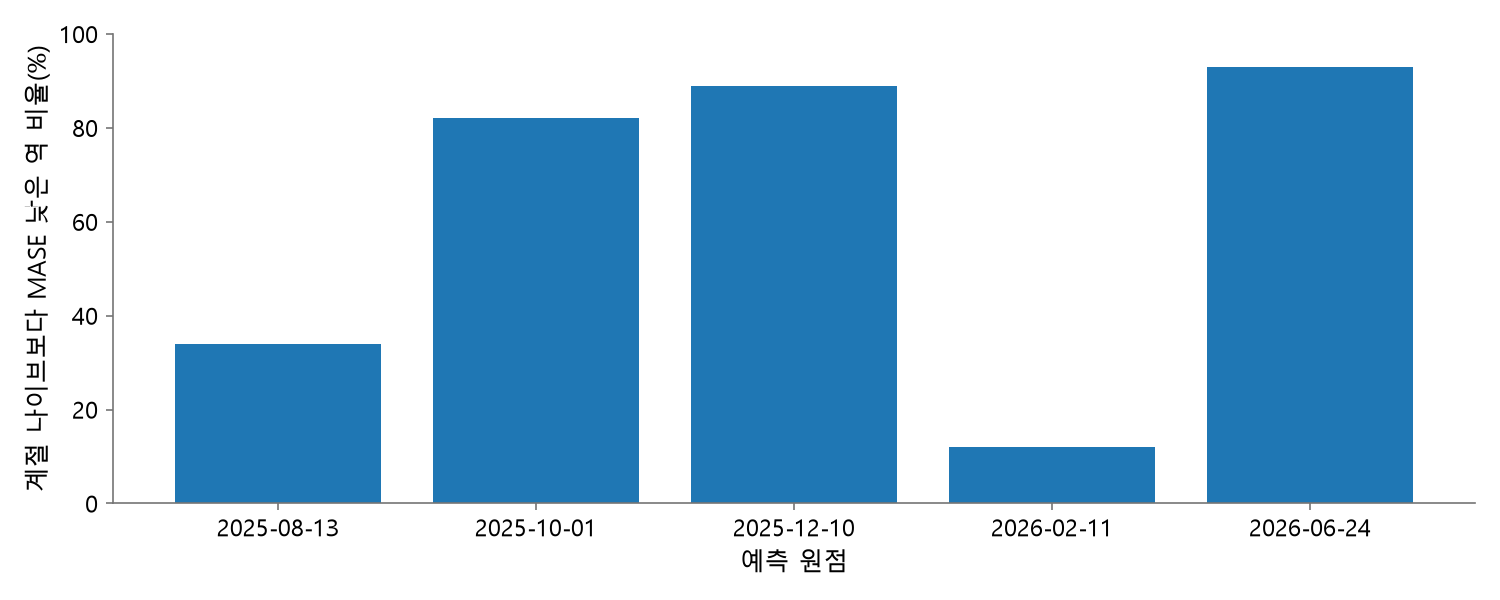

In [5]:
# 미션 1 — 프롬프트   # ai: prompt
# PROMPT 를 쓰고 → AI 튜터에 "위 PROMPT 대로 코드를 써 줘" → 「이 셀에 넣기」 → ▶
# 시킬 일은 AI 튜터 대화창이 아니라 아래 따옴표 안에 적습니다. 예시 프롬프트도 따옴표 안에 붙여 넣어야 채점됩니다
PROMPT = """
공휴일 없는 두 주에 Chronos-2 제로샷 역의 몇 %에서 계절 나이브보다 MASE가 낮을지 출력해야해
본문 쓸 수 있는 것에 나열된 미션 1  코드1의 준비 셀의 변수들은 그대로 사용해

1. 공휴일 없는 두 주 제로샷 평균 MASE: 소수 셋째자리, 원점마다 "0.5" 열로 MASE를 구해 PLAIN_ORIGINS 두 원점을 평균함
2. 공휴일 없는 두 주에서 계절 나이브보다 MASE가 낮은 역 비울: 단위 %, 소수 첫째 자리, 역별 MASE 200개(100개 역 X 원점 2개)
3. 그래프
가로축: 예측 원점
세로축: 계절 나이브보다 MASE가 낮은 역 비율(%)
원점 5개의 비율 막대 세로축 0~100으로 설정
"""
# --- 여기부터 AI 코드 ---
import torch
import numpy as np
import matplotlib.pyplot as plt

QS_LIST = list(QS)
N_STATIONS = len(STATIONS)

def forecast_median(origin):
    ctx = origin_ctx(origin)
    hist = ctx["hist"][:, -CTX:]
    context = torch.tensor(hist, dtype=torch.float32).unsqueeze(1)
    torch.manual_seed(SEED)
    quantiles, _ = PIPE.predict_quantiles(
        inputs=context,
        prediction_length=H,
        quantile_levels=QS_LIST,
    )
    q50 = QS_LIST.index(0.5)
    pred = np.stack([np.asarray(q)[..., q50].reshape(-1) for q in quantiles])
    return ctx, pred

# 1) 공휴일 없는 두 주 제로샷 평균 MASE
plain_mase = []
for origin in PLAIN_ORIGINS:
    ctx, pred = forecast_median(origin)
    m = score(ctx["test"], pred, ctx["qden"])["mase"]
    plain_mase.append(m)
    print(f'{origin}: MASE("0.5") = {m:.3f}')
print(f"공휴일 없는 두 주 제로샷 평균 MASE: {np.mean(plain_mase):.3f}")

# 2) 공휴일 없는 두 주에서 계절 나이브보다 MASE가 낮은 역 비율(%) — 역별 MASE 200개를 합쳐서 비율 하나로
chronos_all = []
snst_all = []
for origin in PLAIN_ORIGINS:
    ctx, pred = forecast_median(origin)
    chronos_all.append(mase_by_station(ctx["test"], pred, ctx["qden"]))
    snst_all.append(SN_ST[origin])
chronos_all = np.concatenate(chronos_all)
snst_all = np.concatenate(snst_all)
below_pct = (chronos_all < snst_all).mean() * 100
print(f"공휴일 없는 두 주에서 계절 나이브보다 MASE가 낮은 역 비율 = {below_pct:.1f}%")

# 3) 원점 5개 막대그래프
all_pct = []
for origin in ORIGINS:
    ctx, pred = forecast_median(origin)
    mase_station = mase_by_station(ctx["test"], pred, ctx["qden"])
    all_pct.append((mase_station < SN_ST[origin]).mean() * 100)

plt.figure(figsize=(FIGW, 4))
plt.bar(ORIGINS, all_pct, color=COL.get("chronos", "tab:blue"))
plt.ylim(0, 100)
plt.xlabel("예측 원점")
plt.ylabel("계절 나이브보다 MASE 낮은 역 비율(%)")
plt.show()

In [6]:
# 미션 2 · 준비 — 읽고 실행만 합니다. 이 셀이 미션 2 에 쓸 이름을 직접 만듭니다
import os, time
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

RAW_URL = "https://github.com/studio-js/seoul-subway-ridership/raw/main/data/seoul_subway_daily_2015_2026.parquet"
CACHE = "seoul_subway_daily.parquet"          # 한 번 받아 두면 다시 받지 않습니다
if not os.path.exists(CACHE):
    pd.read_parquet(RAW_URL).to_parquet(CACHE)

# 첫날과 같은 손질: 역 이름의 괄호 별칭을 떼고 9호선 이름을 맞춘 뒤 (날짜, 호선, 역) 으로 합칩니다
_raw = pd.read_parquet(CACHE)
_raw["date"] = pd.to_datetime(_raw["date"])
_raw["station"] = _raw["station"].astype(str).str.replace(r"\(.*\)$", "", regex=True)
_raw["line"] = _raw["line"].astype(str).replace({"9호선2단계": "9호선(2~3단계)",
                                                "9호선2~3단계": "9호선(2~3단계)"})
_clean = _raw.groupby(["date", "line", "station"], as_index=False,
                      observed=True)[["board", "alight"]].sum()
_span = _clean.groupby(["line", "station"])["date"].agg(["min", "max", "count"])
_full = _span[(_span["min"] <= pd.Timestamp("2015-01-01")) &            # 기록이 끊기지 않은 역만 남긴 뒤
              (_span["max"] >= pd.Timestamp("2026-06-30")) & (_span["count"] >= 4190)]
_top = (_clean[_clean["date"] <= pd.Timestamp("2024-12-31")]             # 2024년까지 평균 승차 상위 100개 역
        .groupby(["line", "station"])["board"].mean()
        .loc[_full.index].sort_values(ascending=False).index[:100])
_wide = _clean.pivot_table(index=["line", "station"], columns="date", values="board").loc[_top]

MAT = _wide.to_numpy(dtype=float)             # 100개 역 x 4,199일 승차 (명)
DATES = pd.DatetimeIndex(_wide.columns)       # 표 열의 날짜
STATIONS = [f"{_line} {_name}" for _line, _name in _wide.index]   # 표 행의 역 이름

ORIGINS = ["2025-08-13", "2025-10-01", "2025-12-10", "2026-02-11", "2026-06-24"]   # 예측 원점 5개 (수요일)
PLAIN_ORIGINS = ["2025-12-10", "2026-06-24"]                                       # 공휴일 없는 두 주
HOL_ORIGINS = ["2025-08-13", "2025-10-01", "2026-02-11"]                           # 공휴일 있는 세 주
H, CTX = 7, 512                               # 채점 7일 · 컨텍스트 512일
QS = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]   # Chronos-2 가 내는 분위수 아홉 개 (점 예측은 0.5)
SEED = 0                                      # 시드
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"   # 설치 셀과 같은 규칙, 이 셀만 실행해도 정해집니다
torch.backends.cuda.matmul.allow_tf32 = False            # fp32 로 계산합니다


def origin_ctx(origin):
    """원점 하나의 자료 — 원점의 열 번호(o), 원점 전날까지의 100개 역(hist), 채점 7일(test, 명), 역별 MASE 분모(qden)"""
    o = int(DATES.get_loc(pd.Timestamp(origin)))
    hist = MAT[:, :o]
    qden = np.nanmean(np.abs(hist[:, 7:] - hist[:, :-7]), axis=1)   # 원점 전날까지로 계산한 분모
    return dict(o=o, hist=hist, test=MAT[:, o:o + H], qden=qden)


def score(y, pred, qden):
    """MASE(역마다 분모로 나눈 절대 오차의 평균)와 RMSE(명)를 사전으로 돌려줍니다"""
    y, pred = np.asarray(y, dtype=float), np.asarray(pred, dtype=float)
    q = np.asarray(qden, dtype=float).reshape(-1, 1)
    return dict(mase=float(np.mean(np.abs(y - pred) / q)),
                rmse=float(np.sqrt(np.mean((y - pred) ** 2))))


# 전임 담당자가 남긴 보고표. 원점마다 7일을 하루씩 예측하며, 예측할 날의 전날 실측까지
#  입력에 넣어 채점한 제로샷 MASE 입니다. 아래 「PROMPT 셀」의 전임 담당자 코드를 그대로 실행하면
#  이 값이 다시 나옵니다. 고친 코드는 이 값을 쓰고, 하루씩 도는 계산을 다시 실행하지 않습니다.
_g, _o = STATIONS.index("2호선 강남"), int(DATES.get_loc(pd.Timestamp("2026-06-24")))
assert tuple(MAT[_g, _o:_o + 3]) == (94303, 94077, 98456)             # 자료 확인 — 강남 6월 24~26일 실측
REPORTED = {"2025-08-13": 1.078524, "2025-10-01": 3.519137, "2025-12-10": 0.269499,
            "2026-02-11": 2.307275, "2026-06-24": 0.248111}

# Chronos-2 를 DEVICE 에 올립니다. 맨 위 설치 셀이 내려받아 둔 가중치를 읽습니다
from chronos import BaseChronosPipeline
_t0 = time.perf_counter()
PIPE = BaseChronosPipeline.from_pretrained("amazon/chronos-2", device_map=DEVICE, torch_dtype=torch.float32)
_load_sec = time.perf_counter() - _t0

print(f"행렬 : {MAT.shape[0]}개 역 x {MAT.shape[1]:,}일 · {DATES[0].date()} ~ {DATES[-1].date()}")
print("원점 5개 :", " · ".join(ORIGINS), f"— 원점마다 원점 전날까지의 {CTX}일을 컨텍스트로 씁니다")
print(f"Chronos-2 : amazon/chronos-2 · fp32 · DEVICE {DEVICE} · 불러오기 {_load_sec:.1f}초 · 학습 없음")
print("전임 담당자의 보고표 (제로샷 MASE, 날마다 다시 예측해 계산) :",
      " · ".join(f"{k} {v:.3f}" for k, v in REPORTED.items()),
      f"(평균 {np.mean(list(REPORTED.values())):.3f})")
print("쓸 수 있는 이름 : MAT · DATES · STATIONS · ORIGINS · PLAIN_ORIGINS · HOL_ORIGINS · H · CTX · QS · SEED"
      " · DEVICE · PIPE · origin_ctx(origin) · score(y, pred, qden) · REPORTED")

Loading weights: 100%|██████████| 170/170 [00:00<00:00, 364.74it/s]

행렬 : 100개 역 x 4,199일 · 2015-01-01 ~ 2026-06-30
원점 5개 : 2025-08-13 · 2025-10-01 · 2025-12-10 · 2026-02-11 · 2026-06-24 — 원점마다 원점 전날까지의 512일을 컨텍스트로 씁니다
Chronos-2 : amazon/chronos-2 · fp32 · DEVICE cpu · 불러오기 1.5초 · 학습 없음
전임 담당자의 보고표 (제로샷 MASE, 날마다 다시 예측해 계산) : 2025-08-13 1.079 · 2025-10-01 3.519 · 2025-12-10 0.269 · 2026-02-11 2.307 · 2026-06-24 0.248 (평균 1.485)
쓸 수 있는 이름 : MAT · DATES · STATIONS · ORIGINS · PLAIN_ORIGINS · HOL_ORIGINS · H · CTX · QS · SEED · DEVICE · PIPE · origin_ctx(origin) · score(y, pred, qden) · REPORTED


7일 뒤 예측의 입력에 있는 원점 뒤 실측 일수 = 0일
7일을 한 번에 예측한 원점 5개 평균 MASE = 1.766
보고표 평균과의 차이 = 0.281


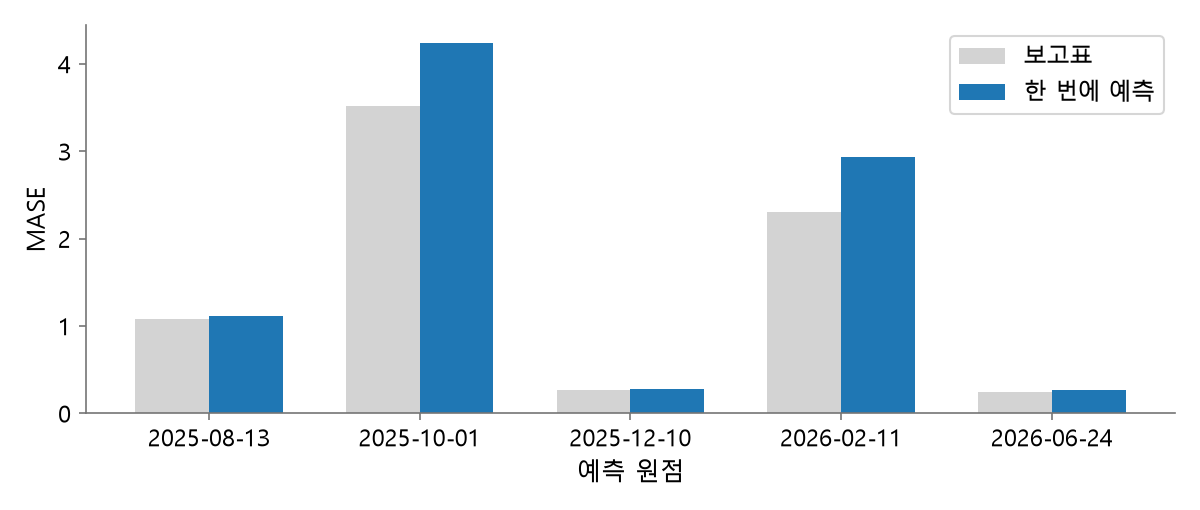

In [7]:
# 미션 2 — 프롬프트 (함정)   # ai: prompt
# 이 미션은 함정입니다 — 아래는 전임 담당자가 남긴 코드라 돌아가지만 답이 틀렸습니다.   # [heavy]
# 어디를 어떻게 고칠지 PROMPT 에 쓰면 튜터가 AI 코드 표시선 아래를 다시 씁니다.
# 고칠 지시는 AI 튜터 대화창이 아니라 아래 따옴표 안에 적습니다. 대화창에만 쓰면 진단은 나오지만 완성본 풀이가 열리지 않습니다
PROMPT = """
전임 담당자 코드를 보았는데 end가 o + h로 되어 있는데 o - 512로 수정해야하는게 아닌가 싶어
뭔가 이 Chronos-2의 입력 512와 예측 7일의 설정이 잘못되어 있는 것 같아.
아래 출력물 나오도록 코드 작성해줘
1. 7일 뒤 예측의 입력에 있는 원점 뒤 실측 일수: 단위 일, 정수, 7일을 한번에 예측하도록 고친 코드에서 7일 뒤 예측의 입력 512일 가운데 날짜가 원점 달일 이후인 날의 개수
2. 보고표 평균과의 차이: 소수 셋째 자리, 7일을 한번에 예측한 원점 5개 평균 MASE에서 REPORTED 다섯 값의 평균을 뺀 값
3. 그래프
가로축 이름: 예측 원점
세로축 이름: MASE
원점마다 보고표 막대와 한번에 에측한 막대를 나란히 둔 그래프
"""
# --- 여기부터 AI 코드 ---
import numpy as np
import torch
import matplotlib.pyplot as plt

QS_LIST = list(QS)
N_STATIONS = len(STATIONS)

def forecast_median(origin):
    ctx = origin_ctx(origin)
    hist = ctx["hist"][:, -CTX:]
    context = torch.tensor(hist, dtype=torch.float32).unsqueeze(1)
    torch.manual_seed(SEED)
    quantiles, _ = PIPE.predict_quantiles(
        inputs=context,
        prediction_length=H,
        quantile_levels=QS_LIST,
    )
    q50 = QS_LIST.index(0.5)
    pred = np.stack([np.asarray(q)[..., q50].reshape(-1) for q in quantiles])
    return ctx, pred

# 1) 7일 뒤 예측의 입력에 원점 뒤 실측이 남아있는지 확인(고친 코드는 0이어야 함)
leak_days = []
for origin in ORIGINS:
    ctx = origin_ctx(origin)
    o = ctx["o"]
    ctx_dates = DATES[o - CTX:o]
    leak_days.append(int((ctx_dates >= DATES[o]).sum()))
max_leak = max(leak_days)
print(f"7일 뒤 예측의 입력에 있는 원점 뒤 실측 일수 = {max_leak}일")

# 2) 7일을 한 번에 예측한 원점 5개 평균 MASE와 보고표 평균의 차이
fixed_mase = {}
for origin in ORIGINS:
    ctx, pred = forecast_median(origin)
    fixed_mase[origin] = score(ctx["test"], pred, ctx["qden"])["mase"]
fixed_avg = np.mean(list(fixed_mase.values()))
reported_avg = np.mean(list(REPORTED.values()))
diff = fixed_avg - reported_avg
print(f"7일을 한 번에 예측한 원점 5개 평균 MASE = {fixed_avg:.3f}")
print(f"보고표 평균과의 차이 = {diff:.3f}")

# 3) 원점마다 보고표 막대와 한 번에 예측한 막대를 나란히
x = np.arange(len(ORIGINS))
width = 0.35
fig, ax = plt.subplots(figsize=(8, 3.4))
ax.bar(x - width / 2, [REPORTED[o] for o in ORIGINS], width, label="보고표", color="lightgray")
ax.bar(x + width / 2, [fixed_mase[o] for o in ORIGINS], width, label="한 번에 예측", color="tab:blue")
ax.set_xticks(x)
ax.set_xticklabels(ORIGINS)
ax.set_xlabel("예측 원점")
ax.set_ylabel("MASE")
ax.legend()
plt.show()